In [1]:
import numpy as np
import sionna
from sionna.rt import load_scene, PlanarArray, Transmitter,Receiver, RadioMapSolver

# 1) 讀取場景並設定中心頻率
scene = load_scene(sionna.rt.scene.munich)
scene.frequency = 3.5e9            # 3.5 GHz 5G
scene.synthetic_array = False
# 2) 共用陣列（你可以分別指定 tx_array / rx_array）
scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             pattern="iso", polarization="V")

# 3) 主基地台 Tx0
scene.remove("tx0")
scene.add(Transmitter("tx0",
                      position=[  0,   0,  20],
                      power_dbm=50))     # 20 W ≈ 43 dBm

# 4) 干擾源 TxJ
scene.add(Transmitter("jammer",
                      position=[150, 100,  10],
                      power_dbm=30))     # 1 W  ≈ 30 dBm
#   也可以改用更定向或水平極化的陣列來模擬指向式干擾

# 5) 建立 Radio‑MapSolver

rm_solver = RadioMapSolver()

rm = rm_solver(scene,max_depth=5,samples_per_tx=int(2e6)) # 地面以上 1.5 m 的橫切面) # 地面以上 1.5 m 的橫切面



(<Figure size 640x480 with 1 Axes>,
 [-27.1431, -26.5114, -25.8798, .. 194 skipped .., 97.2918, 97.9235, 98.5551],
 [0.0034188, 0.0034188, 0.0034188, .. 194 skipped .., 0.996581, 0.998291, 0.998291])

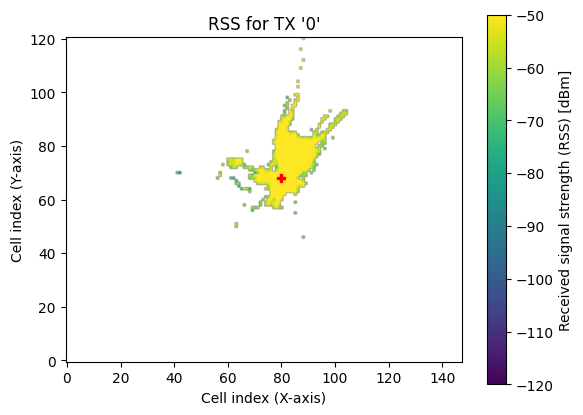

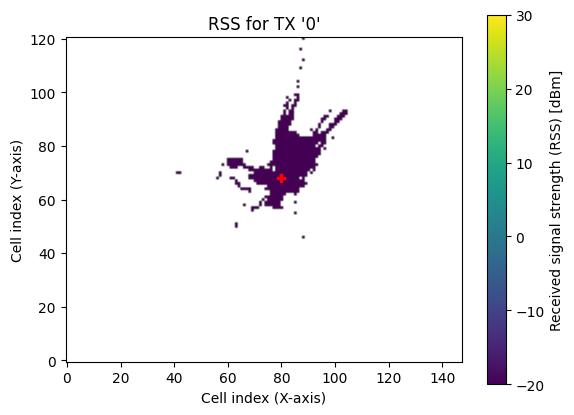

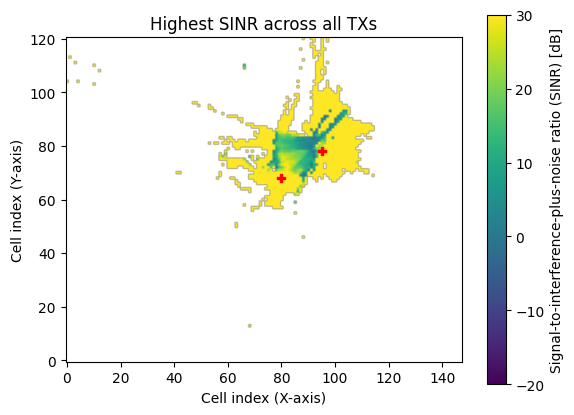

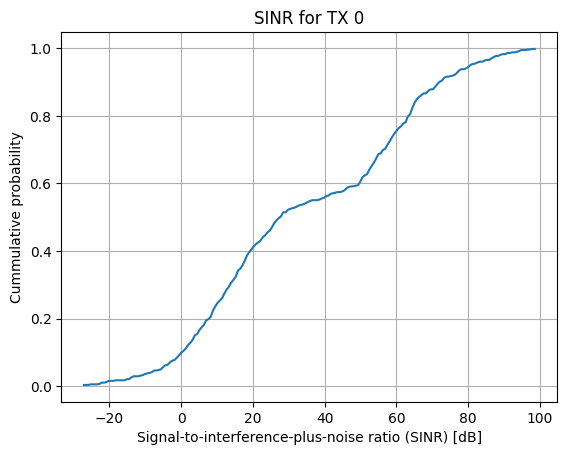

In [3]:
# 干擾功率 (jammer) —> 只選 tx index = 1
rm.show(metric="rss",      tx=0, vmin=-120, vmax=-50)   # 單位 dBm

# SINR (自動把 Tx0 當欲連線基地台，其餘 Tx 都算進干擾)
rm.show(metric="rss",     tx=0, vmin=-20,  vmax=30)

# 如果想看「Receiver 永遠選 SINR 最佳的基地台」：
rm.show(metric="sinr",     tx=None, vmin=-20, vmax=30)

# 把 SINR CDF 輸出成影像或數值
rm.cdf(metric="sinr", tx=0)


In [25]:
# 假设你想要每个 Tx 采 100 个位置
num_pos = 100

pos, cell_ids = rm.sample_positions(
    num_pos,            # 每个 Tx 100 个随机点
    metric="sinr",      # 依据 SINR 过滤
    min_val_db=-np.inf, # 不限制下界
    max_val_db=3,       # SINR ≤ 3 dB
    min_dist=0,         # 与 Tx 的最小距离 ≥ 0 m
    max_dist=150,       # 与 Tx 的最大距离 ≤ 150 m
    tx_association=False,  # 即便不是该 Tx 提供最优 SINR 也可采样
    center_pos=False    # 在格子内部做随机偏移（否则都集中在格点中心）
)

# 返回：
#   pos.shape      == (num_tx, num_pos, 3)
#   cell_ids.shape == (num_tx, num_pos, 2)  # 对应网格索引

# 如果你只关心“干扰源”那颗 Tx（假设它在 rm.tx_list 中索引为 1）：
rx_pos_jammer = pos[1]       # 形状 (100, 3)，每行是 [x, y, z]
ids_jammer    = cell_ids[1]  # 对应格点的 (row, col)



In [27]:
print("干扰源 Tx 采样位置：", rx_pos_jammer)
print("干扰源 Tx 采样格点：", ids_jammer)   
print("shpae of pos:", pos.shape)
print("shpae of cell_ids:", cell_ids.shape)


干扰源 Tx 采样位置： [[89.2573, 20.4825, 1.5],
 [281.207, 102.235, 1.5],
 [81.4599, 103.595, 1.5],
 .. 94 skipped ..,
 [76.6187, 44.2854, 1.5],
 [298.215, 109.292, 1.5],
 [17.6452, 79.9263, 1.5]]
干扰源 Tx 采样格点： [[70, 89],
 [79, 108],
 [79, 88],
 .. 94 skipped ..,
 [73, 88],
 [79, 110],
 [76, 82]]
shpae of pos: (2, 100, 3)
shpae of cell_ids: (2, 100, 2)
